# AI Energy Consumption Optimizer
## Phase 2: Exploratory Data Analysis (EDA)

This notebook will ingest the raw dataset, resample it to an hourly temporal resolution, handle standard formatting issues, and visualize critical trends necessary for our forecasting and anomaly endpoints.

In [1]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define standard base paths
BASE = '/content/drive/MyDrive/energy-optimizer'
RAW_PATH = os.path.join(BASE, 'data/raw/household_power_consumption.csv')

print(f"Target path aligned: {RAW_PATH}")

Mounted at /content/drive
Target path aligned: /content/drive/MyDrive/energy-optimizer/data/raw/household_power_consumption.csv


In [2]:
# 3. Load the dataset carefully
# Note: The raw data uses ';' as delimiter and '?' for missing variables.
print("Loading large CSV, please wait...")
df = pd.read_csv(RAW_PATH, sep=';', na_values=['?'], dtype={'Global_active_power': 'float64'})

# Combine Date & Time into a strictly enforced Datetime index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.set_index('Datetime', inplace=True)

# Drop string columns that are now redundant
df.drop(columns=['Date', 'Time'], inplace=True)

print(f"Loaded Raw Shape: {df.shape}")

Loading large CSV, please wait...
Loaded Raw Shape: (2075259, 7)


In [3]:
# 4. Resample to Hourly Architecture
# Our production API predicts on 1-hour boundaries. Minutely data adds useless noise.
print("Resampling to 1H resolution (taking the .mean() over the hour)...")
df_hourly = df.resample('1H').mean()

# The target column for our endpoints will be `Global_active_power`
# Rename it to 'consumption' for code brevity and API parity
df_hourly.rename(columns={'Global_active_power': 'consumption'}, inplace=True)
print(f"Hourly Shape: {df_hourly.shape}")
df_hourly.head()

Resampling to 1H resolution (taking the .mean() over the hour)...
Hourly Shape: (34589, 7)


/tmp/ipykernel_3910/803347746.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('1H').mean()


,consumption,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


### Missing Value Analysis

In [4]:
# 5. Check missing data distributions
missing_rows = df_hourly['consumption'].isnull().sum()
total_rows = len(df_hourly)
print(f"Total Missing Hours: {missing_rows} / {total_rows} ({missing_rows/total_rows*100:.2f}%)")

# Find lengths of missing gaps to determine gap-fill strategies (Phase 3)
null_series = df_hourly['consumption'].isnull().astype(int)
gaps = null_series.groupby((null_series != null_series.shift()).cumsum()).sum()
gaps = gaps[gaps > 0].sort_values(ascending=False)

print(f"\nLongest consecutive gaps (in hours):")
print(gaps.head(5))
print("\nDecision required for Phase 3: Short gaps (<3h) will be forward-filled. Moderate gaps (<24h) linear interpolation. Massive gaps will be dropped.")

Total Missing Hours: 421 / 34589 (1.22%)

Longest consecutive gaps (in hours):
consumption
14    119
16     87
2      61
6      54
10     52
Name: consumption, dtype: int64

Decision required for Phase 3: Short gaps (<3h) will be forward-filled. Moderate gaps (<24h) linear interpolation. Massive gaps will be dropped.


### Plot 1: Full Historical Timeline & Macro Distribution

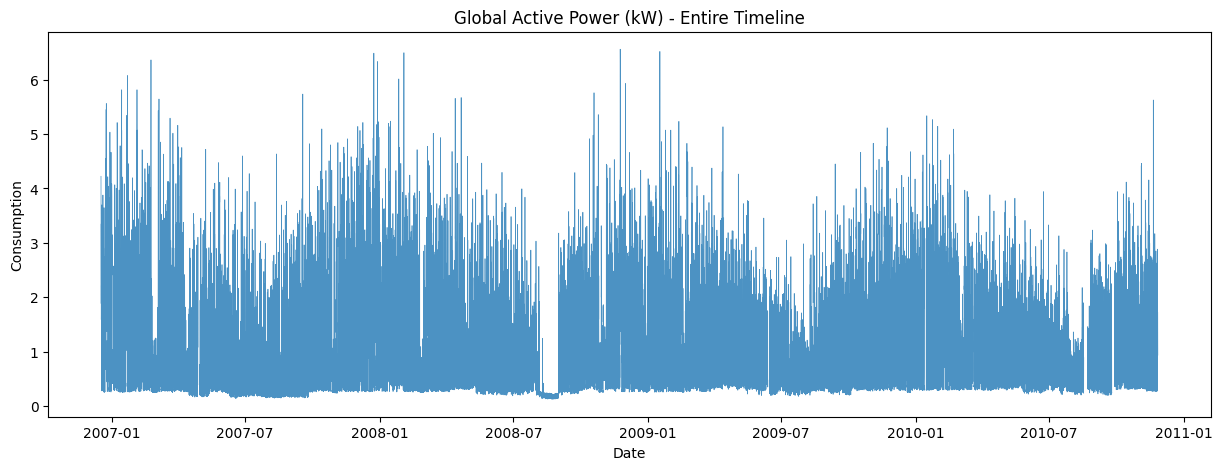

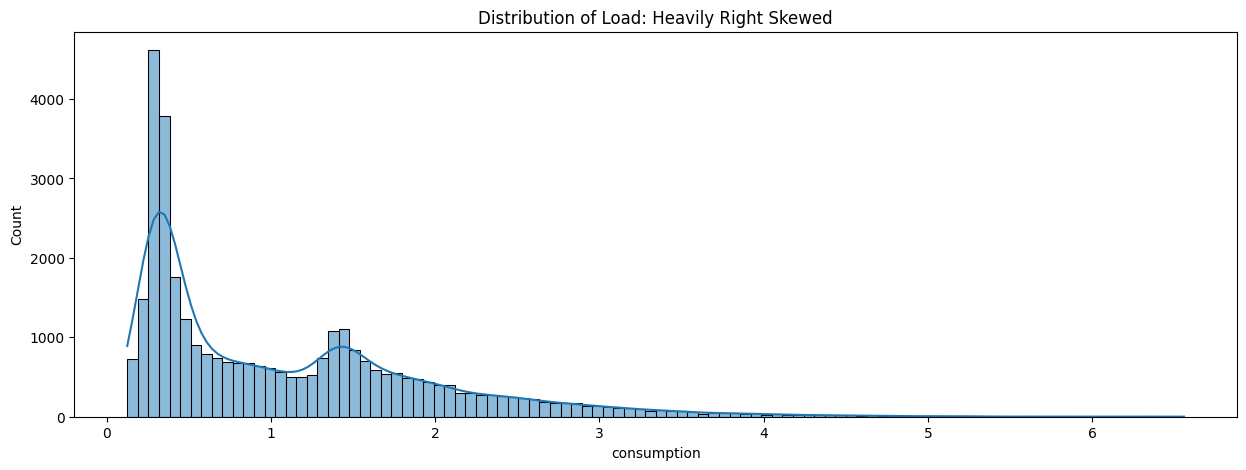

In [5]:
plt.figure(figsize=(15, 5))
plt.plot(df_hourly.index, df_hourly['consumption'], linewidth=0.5, alpha=0.8)
plt.title('Global Active Power (kW) - Entire Timeline')
plt.xlabel('Date')
plt.ylabel('Consumption')
plt.show()

plt.figure(figsize=(15, 5))
sns.histplot(df_hourly['consumption'].dropna(), bins=100, kde=True)
plt.title('Distribution of Load: Heavily Right Skewed')
plt.show()

### Plot 2: Discovering Seasonalities (Daily, Weekly, Monthly)

/tmp/ipykernel_3910/1994873988.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hourly, x='hour', y='consumption', ax=axes[0], palette="viridis")
/tmp/ipykernel_3910/1994873988.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hourly, x='dayofweek', y='consumption', ax=axes[1], palette="coolwarm")
/tmp/ipykernel_3910/1994873988.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hourly, x='month', y='consumption', ax=axes[2], palette="magma")


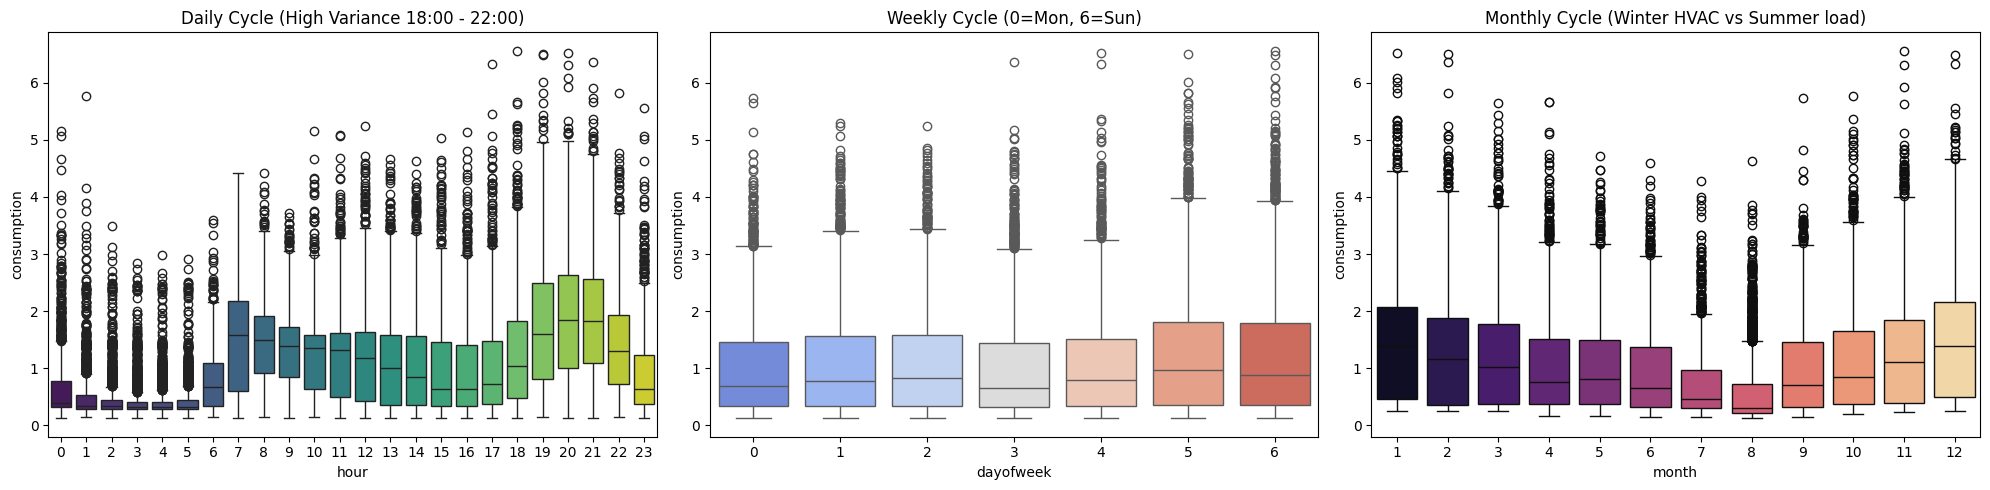

In [6]:
# Add temp features strictly for EDA visualization
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek # 0=Mon, 6=Sun
df_hourly['month'] = df_hourly.index.month

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(data=df_hourly, x='hour', y='consumption', ax=axes[0], palette="viridis")
axes[0].set_title("Daily Cycle (High Variance 18:00 - 22:00)")

sns.boxplot(data=df_hourly, x='dayofweek', y='consumption', ax=axes[1], palette="coolwarm")
axes[1].set_title("Weekly Cycle (0=Mon, 6=Sun)")

sns.boxplot(data=df_hourly, x='month', y='consumption', ax=axes[2], palette="magma")
axes[2].set_title("Monthly Cycle (Winter HVAC vs Summer load)")

plt.tight_layout()
plt.show()

### Plot 3: Temporal Lags (ACF / PACF)
This mathematically proves to the API buffer which history lags (T-1, T-x) are worth saving.

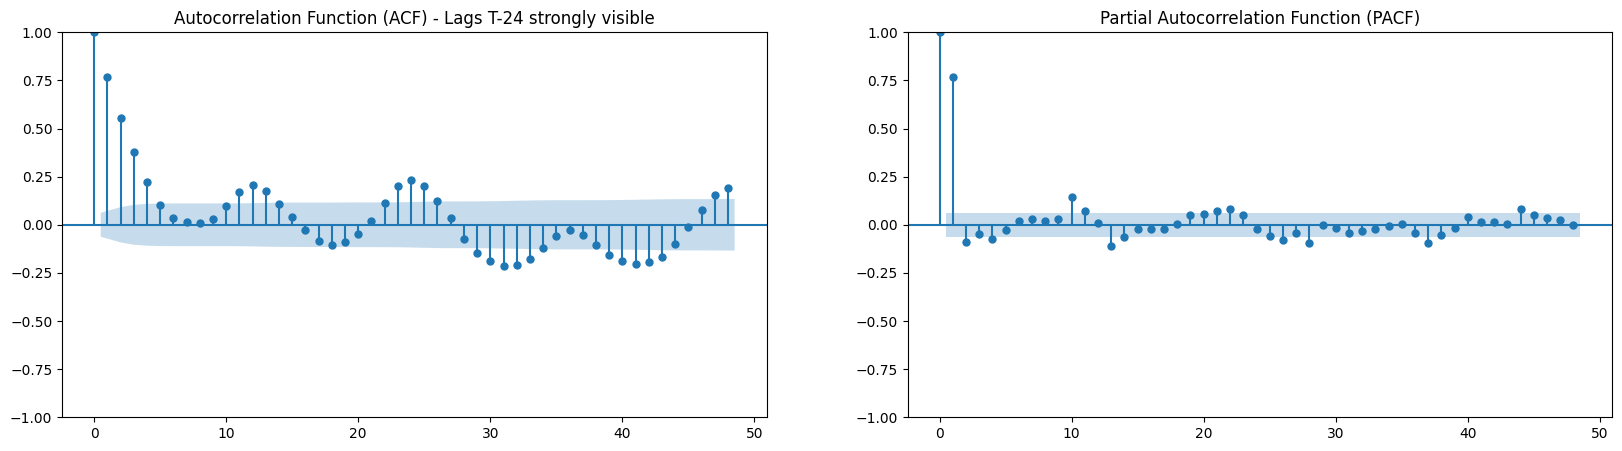

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
# Using a cleanly sliced segment rather than the entire frame to speed up plot rendering
clean_series = df_hourly['consumption'].dropna().head(1000)
plot_acf(clean_series, lags=48, ax=ax1, title="Autocorrelation Function (ACF) - Lags T-24 strongly visible")
plot_pacf(clean_series, lags=48, ax=ax2, title="Partial Autocorrelation Function (PACF)")
plt.show()

#### 📝 *Documentation:* Lag Features determined from PACF for Phase 3 Feature Engineering:
- `t-1` (Immmediate Recency)
- `t-2`
- `t-24` (Exact same hour yesterday)
- `t-48`
- `t-168` (Exact same hour last week)

### Visual Feature Check: Anomalies
We need to document 2 real anomalies to compare against the FastAPI Isolation Forest later.

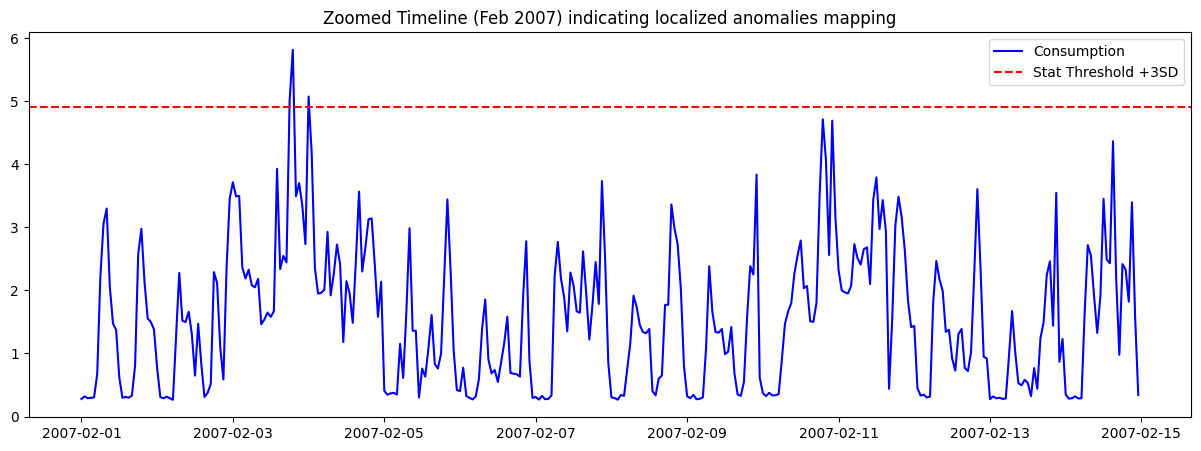

In [8]:
plt.figure(figsize=(15, 5))
slice_df = df_hourly['2007-02-01':'2007-02-14']
plt.plot(slice_df.index, slice_df['consumption'], label="Consumption", color='blue')
plt.axhline(slice_df['consumption'].mean() + (3*slice_df['consumption'].std()), color='red', linestyle='--', label='Stat Threshold +3SD')
plt.title('Zoomed Timeline (Feb 2007) indicating localized anomalies mapping')
plt.legend()
plt.show()

In [9]:
# Drop temporary EDA columns to return df_hourly back to its pure form before passing down pipeline
df_hourly.drop(columns=['hour', 'dayofweek', 'month'], inplace=True, errors='ignore')